In [ ]:
import sys
import os
import jax
import jax.numpy as np
import jax.tree as jtu
import jax.random as jr
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Basic jax import
jax.config.update("jax_enable_x64", True)


# Check if running on remote, and set directory to where notebook is run
if jax.devices()[0].platform == "gpu":
    os.chdir("code/amigo_project/notebooks/calibration")

# Add parent directories
paths = [os.path.abspath(os.path.join(os.getcwd(), path)) for path in ['..', "../.."]]
for path in paths:
    if path not in sys.path:
        sys.path.insert(0, path)
        
# Plotting set up
%matplotlib inline
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 120

inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]
inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)


def merge_cbar(ax):
    return make_axes_locatable(ax).append_axes("right", size="5%", pad=0.0)

In [2]:
filters = ["F380M", "F430M", "F480M"]

cal_vis_outputs = {}
for filt in filters:
    cal_vis_dict = np.load(f"../../GPU_files/temp/1843/{filt}.npy", allow_pickle=True).item()
    cal_vis_outputs[filt] = cal_vis_dict

(190, 190)
(190, 190)
(190,)
(190,)


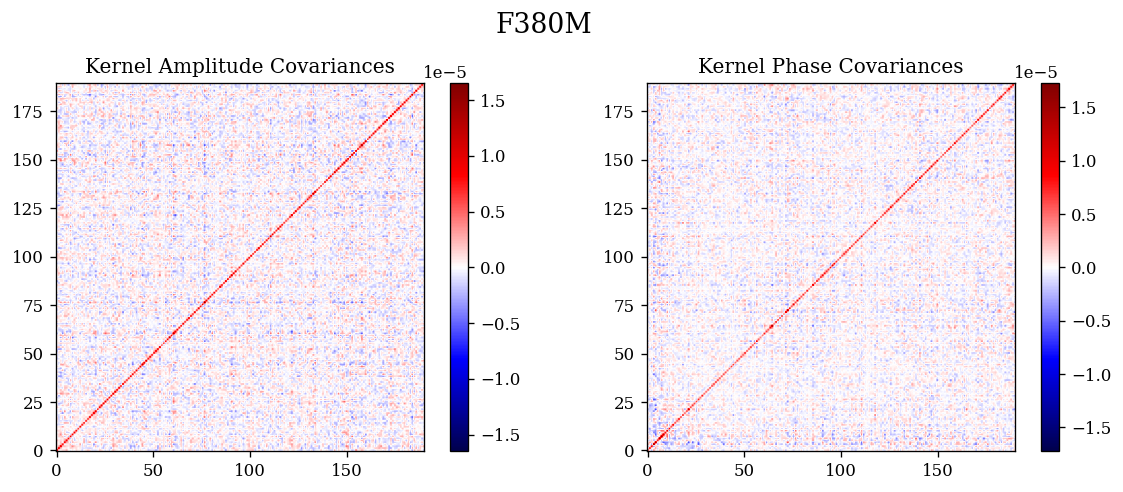

(190, 190)
(190, 190)
(190,)
(190,)


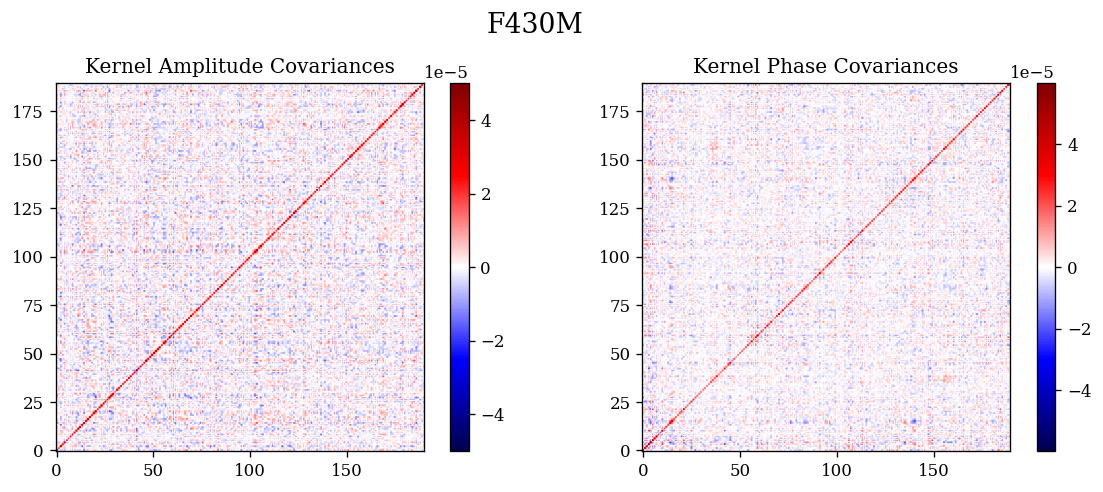

(190, 190)
(190, 190)
(190,)
(190,)


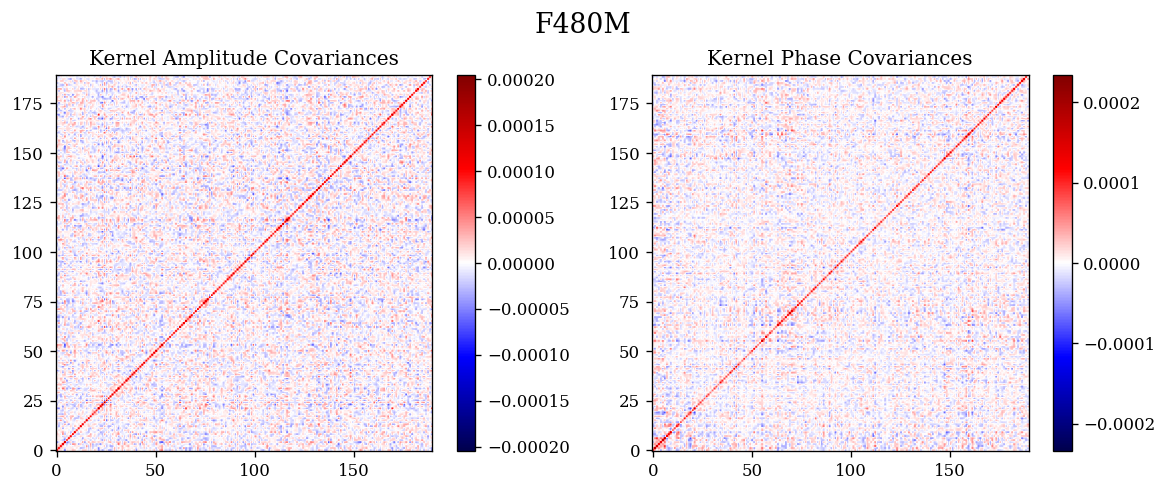

In [19]:
for filt, cal_vis in cal_vis_outputs.items():
    vis_cov = cal_vis["K_vis_cov"][10:200, 10:200]
    phi_cov = cal_vis["K_phi_cov"][10:200, 10:200]

    vals, vecs= np.linalg.eig(vis_cov)
    vecs = np.real(vecs)
    vals = np.real(vals)

    print(vis_cov.shape)
    print(vecs.shape)
    print(vals.shape)
    print(vals.shape)

    new_vis_cov = np.dot(vecs, np.dot(vis_cov, vecs.T))
    vis_cov = new_vis_cov

    plt.figure(figsize=(10, 4))
    plt.suptitle(filt, fontsize=16)

    v = np.nanmax(np.abs(vis_cov))
    plt.subplot(1, 2, 1)
    plt.title("Kernel Amplitude Covariances")
    # plt.imshow(np.log10(np.abs(vis_cov)), inferno)
    plt.imshow(vis_cov, seismic, vmin=-v, vmax=v)
    plt.colorbar()

    v = np.nanmax(np.abs(phi_cov))
    plt.subplot(1, 2, 2)
    plt.title("Kernel Phase Covariances")
    # plt.imshow(np.log10(np.abs(phi_cov)), inferno)
    plt.imshow(phi_cov, seismic, vmin=-v, vmax=v)
    plt.colorbar()

    plt.tight_layout()
    plt.show()

In [3]:
# jtu.map(lambda x: x.shape, cal_vis_outputs)

In [4]:
# amp = 100 * (np.exp(amps) - 1)
# amp = (-amps / 100)

In [5]:
import equinox as eqx
import zodiax as zdx

class AmigoOIData(zdx.Base):
    # Coordinates
    u: np.ndarray
    v: np.ndarray
    wavel: np.ndarray
    parang: np.ndarray

    # Kernel Visibilities
    K_vis: np.ndarray
    dK_vis: np.ndarray

    # Kernel Phases
    K_phi: np.ndarray
    dK_phi: np.ndarray

    # Latent space projection matrices
    vis_mat: np.ndarray  # Latent -> Pixel
    phi_mat: np.ndarray  # Latent -> Pixel
    vis_mat_inv: np.ndarray  # Pixel -> Latent
    phi_mat_inv: np.ndarray  # Pixel -> Latent

    # Kernel projection matrices
    K_vis_mat: np.ndarray  # Latent -> Null
    K_phi_mat: np.ndarray  # Latent -> Null
    K_vis_mat_inv: np.ndarray  # Null -> Latent
    K_phi_mat_inv: np.ndarray  # Null -> Latent

    def __init__(self, oi_data):
        """
        Default should have vis, phi as their _latent_ values
        """
        self.u = -np.array(oi_data["u"], dtype=float)
        self.v = -np.array(oi_data["v"], dtype=float)
        self.wavel = np.array(oi_data["wavel"], dtype=float)
        self.parang = np.array(oi_data["parang"], dtype=float)

        #
        self.K_vis = np.array(oi_data["K_vis"], dtype=float)
        self.K_phi = np.array(oi_data["K_phi"], dtype=float)

        #
        self.dK_phi = np.diag(oi_data["K_phi_cov"]) ** 0.5
        self.dK_vis = np.diag(oi_data["K_vis_cov"]) ** 0.5

        # Latent space
        self.vis_mat = np.array(oi_data["vis_mat"], dtype=float)
        self.phi_mat = np.array(oi_data["phi_mat"], dtype=float)
        self.vis_mat_inv = np.linalg.pinv(self.vis_mat)
        self.phi_mat_inv = np.linalg.pinv(self.phi_mat)

        # Kernel space
        self.K_vis_mat = np.array(oi_data["K_vis_mat"], dtype=float)
        self.K_phi_mat = np.array(oi_data["K_phi_mat"], dtype=float)
        self.K_vis_mat_inv = np.linalg.pinv(self.K_vis_mat)
        self.K_phi_mat_inv = np.linalg.pinv(self.K_phi_mat)

        # # Operators and projection matrices
        # self.V = np.array(oi_data["V"], dtype=float)
        # self.V_inv = np.linalg.pinv(self.V)
        # self.K = np.array(oi_data["K"], dtype=float)
        # self.K_inv = np.linalg.pinv(self.K)

    def latent_to_pixel(self, latent_vis):
        return np.dot(latent_vis, self.V)

    def latent_to_null(self, latent_vis):
        # return np.dot(latent_vis, self.K)
        return np.dot(self.K, latent_vis)

    def pixel_to_latent(self, vis_vec):
        return np.dot(vis_vec, self.V_inv)

    def null_to_latent(self, K_vis):
        return np.dot(K_vis, self.K_inv)

    def flatten_data(self):
        """ Flatten closure phases and uncertainties."""
        vis_vec = np.concatenate([self.K_vis, self.K_phi])
        vis_err = np.concatenate([self.dK_vis, self.dK_phi])
        return vis_vec, vis_err

    def flatten_model(self, cvis):
        """
        cvis: complex visibilities from model
        Flatten model visibilities and phases.
        """
        # Project the visibilities to the latent then null space
        log_cvis = np.log(cvis)
        log_vis, phi = log_cvis.real, log_cvis.imag
        log_vis = np.dot(log_vis, self.vis_mat_inv)
        phi = np.dot(phi, self.phi_mat_inv)

        K_vis = np.dot(self.K_vis_mat, log_vis)
        K_phi = np.dot(self.K_phi_mat, phi)
        return np.concatenate([K_vis, K_phi])

    def model(self, model_object):
        """
        Compute the model visibilities and phases for the given model object.
        """
        cvis = model_object.model(self.u, self.v, self.wavel)
        return self.flatten_model(cvis)

    # Overwrite this, it was a mistake from the beginning
    def __repr__(self):
        return eqx.Module.__repr__(self)

In [6]:
import jax.numpy as np
import optimistix as optx
from jax import vmap
import dLux.utils as dlu
from jax.scipy.stats import norm


@eqx.filter_jit
def loglike(values, params, data_obj, model_class):
    """
    Abstract log-likelihood function for a given model class and data object, assuming
    Gaussian errors.

    Parameters
    ----------
    values : array-like
        Values of the model parameters.
    params : list
        List of parameter names.
    data_obj : OIData
        Object containing the data to be fitted.
    model_class : class
        Model class to be fitted to the data.

    Returns
    -------
    float
        Log-likelihood value.
    """
    model_data = data_obj.model(model_class(**dict(zip(params, values))))
    data, errors = data_obj.flatten_data()
    return norm.logpdf(model_data, loc=data, scale=errors).sum()


def likelihood_grid(data_obj, model_class, samples_dict, n_batch=50):
    """
    Function to vmap a likelihood function over a grid of parameter values provided in
    a dictionary.

    Parameters
    ----------
    data_obj : OIData
        Object containing the data to be fitted.
    model_class : class
        Model class to be fitted to the data.
    samples_dict: dict
        Dictionary of parameter names and values to be fitted to the data.

    Returns
    -------
    array-like
        Log-likelihood values over the grid of parameter values.
    """

    params = list(samples_dict.keys())
    samples = samples_dict.values()
    vals = np.array(np.meshgrid(*samples))
    vals_vec = vals.reshape((len(vals), -1)).T

    # NOTE: Is this dimensionally robust? How do we know what which output axis is
    # which? Seems it could be ordered by the dictionary key
    fn = eqx.filter_jit(
        vmap(lambda values: loglike(values, params, data_obj, model_class))
    )
    # return batched_fn(fn, vals_vec, n_batch=n_batch)

    batches = np.array_split(vals_vec, n_batch)
    out = []
    for batch in batches:
        out.append(fn(batch))
    out = np.concatenate(out)
    return out.reshape(vals.shape[1:])  # check the shapes output here


def optimized_contrast_grid(data_obj, model_class, samples_dict, n_batch=50):
    """
    Function to optimize the contrast of a model over a grid of parameter values
    provided in a dictionary.

    Parameters
    ----------
    best_contrast_indices : array-like
        Indices of the best contrast values in a grid calculated with likelihood_grid.
    data_obj : OIData
        Object containing the data to be fitted.
    model_class : class
        Model class to be fitted to the data.
    samples_dict: dict
        Dictionary of parameter names and values to be fitted to the data.

    Returns
    -------
    array-like
        Optimized contrast values over the grid of parameter values.

    """
    params = list(samples_dict.keys())

    loglike_im = likelihood_grid(data_obj, model_class, samples_dict, n_batch=n_batch)
    # loglike_im = fn(vals_vec).reshape(vals.shape[1:]) # check the shapes output here
    best_contrast_indices = np.argmax(loglike_im, axis=2)

    # then do optimization to fine tune the contrast
    coords = [samples_dict[key] for key in ["dra", "ddec"]]
    ras, decs = np.meshgrid(*coords)
    vals = np.array([samples_dict["flux"][best_contrast_indices].T, decs, ras])
    vals_vec = vals.reshape((len(vals), -1)).T

    to_optimize = lambda flux, dra_inp, ddec_inp: -loglike(
        [dra_inp, ddec_inp, flux], params, data_obj, model_class
    )
    bestcon = lambda flux, dra, ddec: optx.compat.minimize(
        to_optimize,
        x0=np.array([flux]),
        args=(np.array(dra), np.array(ddec)),
        method="BFGS",
        options={"maxiter": 100},
    ).x

    fn = eqx.filter_jit(vmap(lambda values: bestcon(*values)))
    # return batched_fn(fn, vals_vec, n_batch=n_batch).T  # check the shapes output here

    batches = np.array_split(vals_vec, n_batch)
    out = []
    for batch in batches:
        out.append(fn(batch))
    out = np.concatenate(out)
    return out.reshape(vals.shape[1:]).T  # check the shapes output here

In [7]:
from drpangloss.models import BinaryModelCartesian


def fit_oi_data(
    grid,
    oi_data,
    amp_scale=1.0,
    phi_scale=1.0,
    # Kphi_scale=1.0,
    n_batch=50,
    use_null=False,
    obj=AmigoOIData,
):
    # Scale the errors
    oi_obj = obj(oi_data)  # , use_null_phase=use_null)
    oi_obj = oi_obj.multiply("dK_vis", amp_scale)
    oi_obj = oi_obj.multiply("dK_phi", phi_scale)
    # oi_obj = oi_obj.multiply("d_null_vis", Kphi_scale)

    # NOTE: The log-likelihood image seems to come out (Dec, RA), so we _dont_ need to
    # transpose the output
    # Log-likelihood
    loglike_im = likelihood_grid(oi_obj, BinaryModelCartesian, grid, n_batch=n_batch)
    loglike_im = loglike_im.max(axis=2)

    # NOTE: The Contrast image seems to come out (RA, Dec), so we transpose the output
    # Best contrast
    contrast_im = optimized_contrast_grid(
        oi_obj, BinaryModelCartesian, grid, n_batch=n_batch
    )
    contrast_im = np.where(contrast_im < 0, 0, contrast_im).T

    # # Get the FoVs
    r_bls = np.hypot(oi_data["u"], oi_data["v"])
    min_bls, max_bls = r_bls.min(), r_bls.max()
    min_fov = 1e3 * dlu.rad2arcsec(oi_data["wavel"] / (2 * max_bls))
    max_fov = 1e3 * dlu.rad2arcsec(oi_data["wavel"] / (2 * min_bls))

    # Mask the fov
    rs = np.hypot(*np.meshgrid(grid["dra"], grid["ddec"]))
    r_max = np.minimum(max_fov, 2 * grid["dra"].max())
    # rmask = (rs > min_fov / 2) & (rs <= r_max / 2)
    rmask = (rs > 200 / 2) & (rs <= r_max / 2)
    loglike_im = np.where(rmask, loglike_im, np.nan)
    contrast_im = np.where(rmask, contrast_im, np.nan)

    # Return the images
    return loglike_im, contrast_im, (min_fov, max_fov)

In [8]:

# Samples
n = 60
size = 350  # mas

  0%|          | 0/3 [00:00<?, ?it/s]

RA: -331.93
Dec: -273.11
F380M: -inf
F430M: -inf
F480M: -5.35


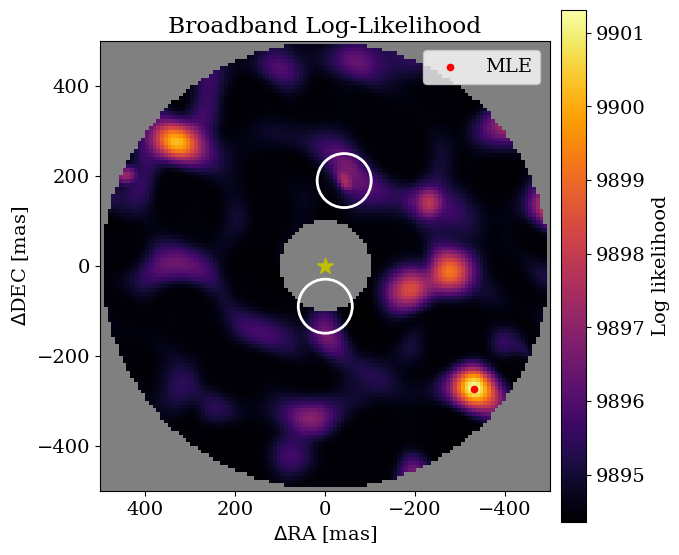

In [9]:
import dLux.utils as dlu
import matplotlib.patches as patches
from amigo.misc import tqdm

# # Values from here, Fig 16: 
# # https://www.stsci.edu/files/live/sites/www/files/home/jwst/documentation/_documents/jwst-science-performance-report.pdf
# pa, sep = -79.4, 325.6
# ra = sep * np.sin(dlu.deg2rad(pa))
# dec = sep * np.cos(dlu.deg2rad(pa))
binaries = [
    (-43, 189),  # Ra, Dec
    (-1, -90),  # Ra, Dec
]


# Samples
n = 120
size = 500 # mas
RAs = np.linspace(size, -size, n)
Decs = np.linspace(-size, size, n)
fluxes = np.linspace(-6, 0, n)
grid = {"dra": RAs, "ddec": Decs, "flux": 10 ** fluxes}


# Calculate the log-likelihoods
loglike_ims, contrast_ims, fovs = {}, {}, {}
for filt, oi_data in tqdm(cal_vis_outputs.items()):
    loglike_im, contrast_im, fov = fit_oi_data(
        grid, oi_data, 
        amp_scale=1,
        phi_scale=1,
        n_batch=500, 
        use_null=True,
    )
    loglike_ims[filt] = loglike_im
    contrast_ims[filt] = contrast_im
    fovs[filt] = fov

# Get the MLEs
loglike_im = np.array(jtu.leaves(loglike_ims)).sum(axis=0)
dec_ind, ra_ind = np.where(loglike_im == np.nanmax(loglike_im))
contrast_mles = jtu.map(lambda x: np.log10(x[*dec_ind, *ra_ind]), contrast_ims)
ra_mle, dec_mle = RAs[*ra_ind], Decs[*dec_ind]

# print("(RA, Dec)")
print(f"RA: {ra_mle:.2f}")
print(f"Dec: {dec_mle:.2f}")
[print(f"{filt}: {contrast:.2f}") for filt, contrast in contrast_mles.items()]


#
extent = (RAs[0], RAs[-1], Decs[0], Decs[-1])
make_circle = lambda position, diameter, **kwargs: patches.Circle(
    position, diameter / 2, color="w", fill=False, linewidth=2, **kwargs
)

plt.figure(figsize=(7, 7))
ax = plt.subplot(1, 1, 1)
plt.imshow(loglike_im, cmap=inferno, aspect="equal", extent=extent)
plt.colorbar(shrink=0.95, label="Log likelihood", pad=0.02)
plt.scatter(0, 0, s=140, c="y", marker="*")
ax.set(title="Broadband Log-Likelihood", xlabel="$\\Delta$RA [mas]", ylabel="$\\Delta$DEC [mas]",)
ax.scatter(ra_mle, dec_mle, s=80, c="r", marker=".", label="MLE")
[ax.add_patch(make_circle(binary, 120)) for binary in binaries]
# ax.add_patch(make_circle((0, 0), diff_lim, ls="--", label="Diffraction limit"))
ax.legend()
plt.show()

In [10]:
from amigo.optical_models import AMIOptics

optics = AMIOptics()

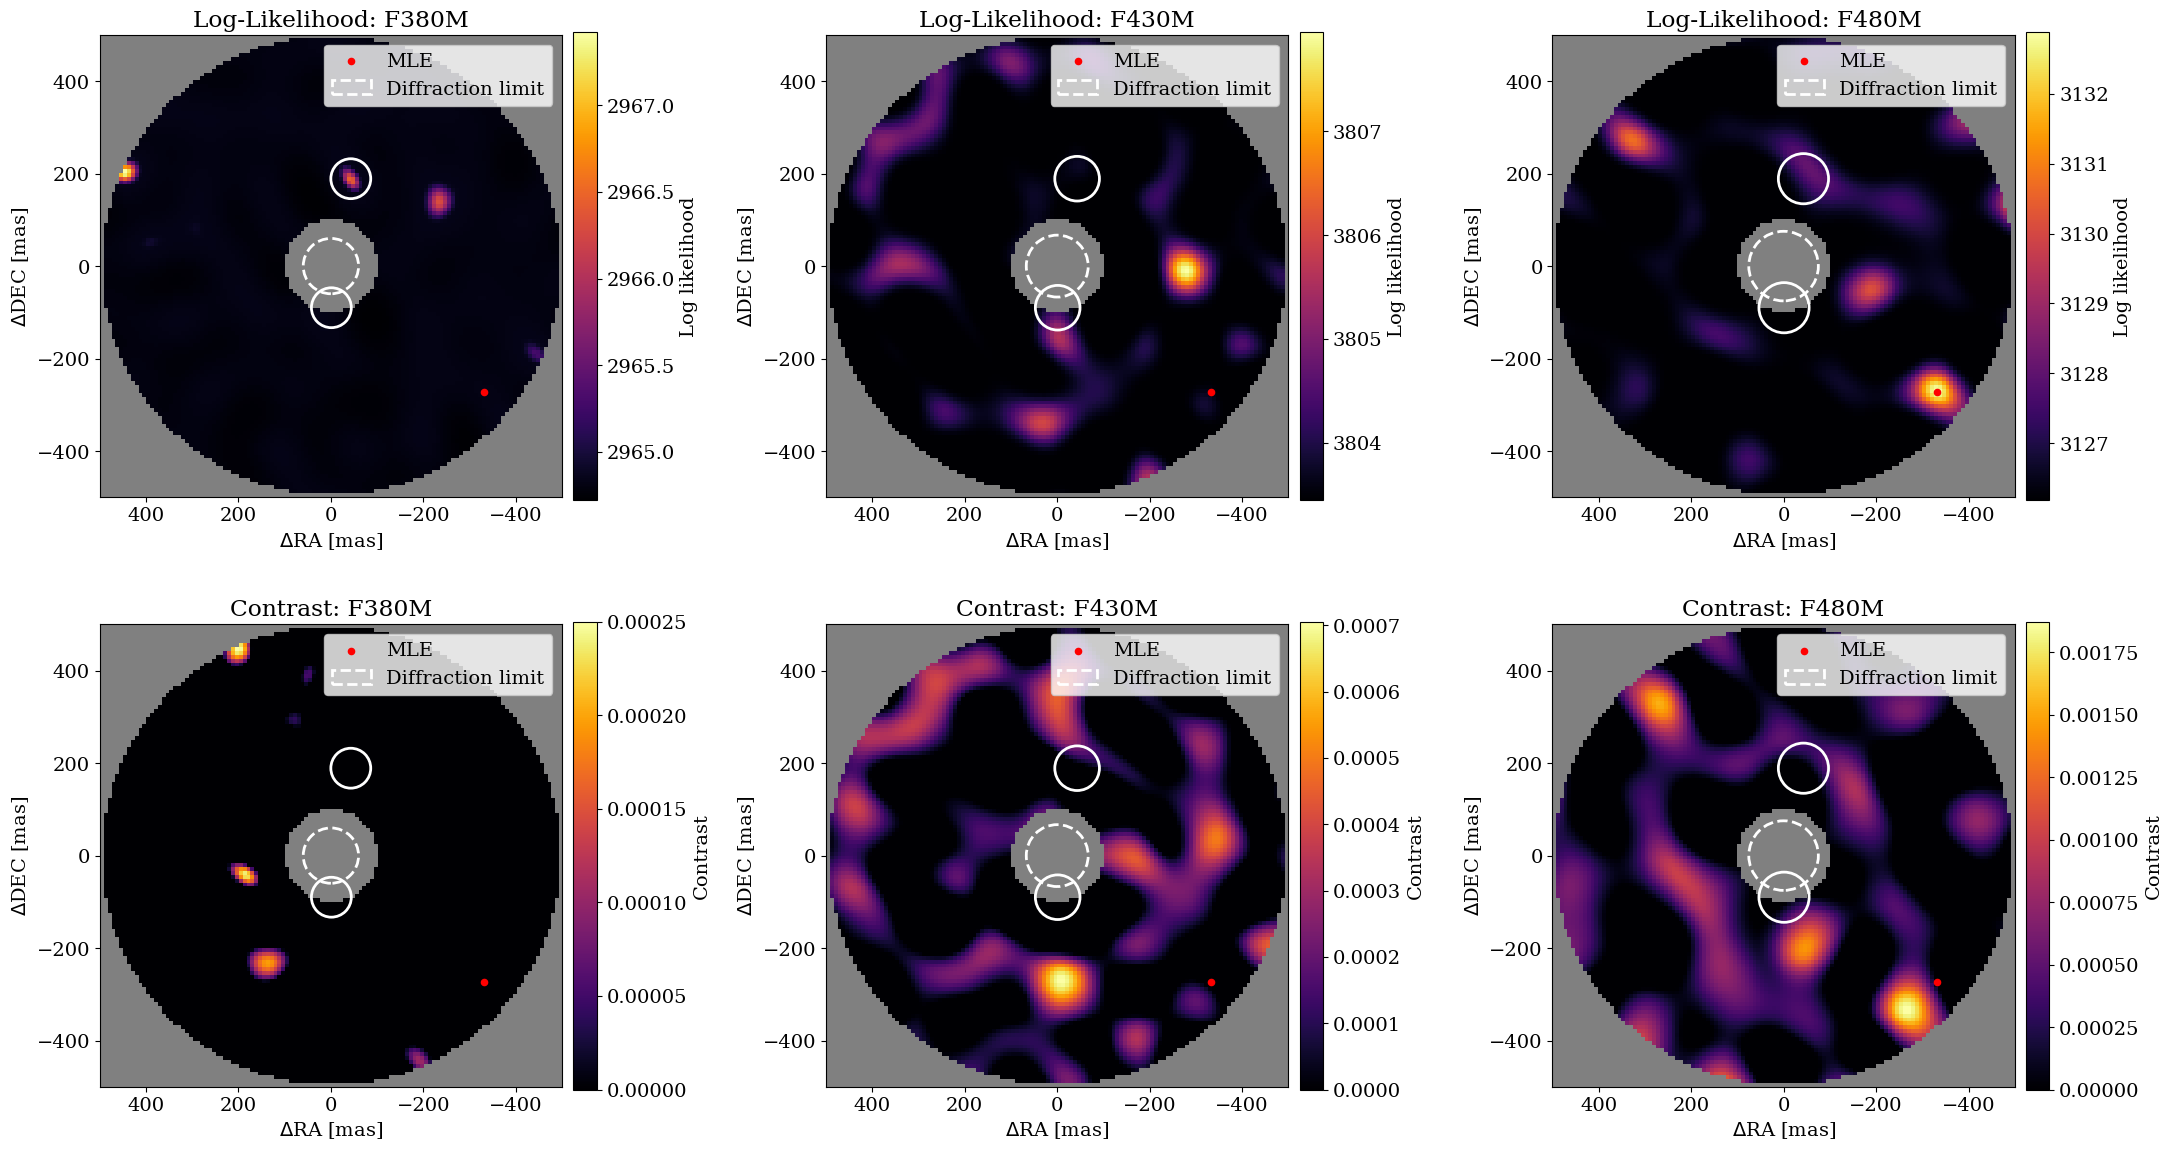

In [11]:

plt.figure(figsize=(22, 12))
for i, filt in enumerate(loglike_ims.keys()):
    loglike_im = loglike_ims[filt]
    contrast_im = contrast_ims[filt]
    oi_data = cal_vis_outputs[filt]
    min_fov, max_fov = fovs[filt]
    wavel = oi_data["wavel"]

    diff_lim = 1e3 * dlu.rad2arcsec(wavel / optics.diameter)

    def add_to_ax(ax):
        ax.scatter(ra_mle, dec_mle, s=80, c="r", marker=".", label="MLE")
        [ax.add_patch(make_circle(binary, 2*min_fov)) for binary in binaries]
        ax.add_patch(make_circle((0, 0), diff_lim, ls="--", label="Diffraction limit"))
        ax.legend()

    #
    ax1 = plt.subplot(2, 3, i + 1)
    plt.imshow(loglike_im, cmap=inferno, aspect="equal", extent=extent)
    plt.colorbar(shrink=0.95, label="Log likelihood", pad=0.02)
    ax1.set(
        title=f"Log-Likelihood: {filt}",
        xlabel="$\\Delta$RA [mas]",
        ylabel="$\\Delta$DEC [mas]",
    )
    add_to_ax(ax1)

    ax2 = plt.subplot(2, 3, i + 4)
    plt.imshow(contrast_im, cmap=inferno, aspect="equal", extent=extent, vmin=0)
    plt.colorbar(shrink=0.95, label="Contrast", pad=0.02)
    ax2.set(
        title=f"Contrast: {filt}",
        xlabel="$\\Delta$RA [mas]",
        ylabel="$\\Delta$DEC [mas]",
    )
    add_to_ax(ax2)

plt.tight_layout()
plt.show()

In [12]:
import numpyro as npy
import numpyro.distributions as dist

ra, dec = binaries[0]
# ra, dec = binaries[1]

def sampling_fn(oi_data_obj, model_class):

    # Define priors
    r = 75
    dra = npy.sample("Δ RA", dist.Uniform(ra - r, ra + r))
    ddec = npy.sample("Δ Dec", dist.Uniform(dec - r, dec + r))
    log_flux = npy.sample("log Flux", dist.Uniform(-5, -2))
    errorscale = npy.sample("jitter", dist.Uniform(0.0, 2.0))

    # Track the outputs of the model and the PA/Sep/DMag
    # _ = npy.deterministic("PA", dlu.rad2deg(np.arctan2(dra, dec)))
    _ = npy.deterministic("PA", dlu.rad2deg(np.arctan2(dec, dra)))
    _ = npy.deterministic("Sep", np.hypot(dra, ddec))
    _ = npy.deterministic("Δ Mag", -2.5 * log_flux)
    pred_data = npy.deterministic(
        "pred", oi_data_obj.model(model_class(dra, ddec, 10**log_flux))
    )

    data, errors = oi_data_obj.flatten_data()
    model_sampler = dist.Normal(pred_data, errors * 10**errorscale)
    return npy.sample("Sampler", model_sampler, obs=data)

In [13]:
from drpangloss.models import OIData, BinaryModelCartesian
# from amigo.vis_analysis import AmigoOIData

samplers, oi_objs = {}, {}

for i, (filt, oi_data) in enumerate(cal_vis_outputs.items()):
    # if not filt == "F380M":
    #     continue
    oi_data_obj = AmigoOIData(oi_data)
    oi_data_obj = oi_data_obj.multiply("dK_vis", 1)
    oi_data_obj = oi_data_obj.multiply("dK_phi", 1)

    sampler = npy.infer.MCMC(
        npy.infer.NUTS(sampling_fn),
        num_warmup=10000,
        num_samples=10000,
    )
    sampler.run(jr.PRNGKey(0), oi_data_obj, BinaryModelCartesian)

    posterior_pred = sampler.get_samples()["pred"]
    print(f"{filt}: Error scaling:", 10 ** sampler.get_samples()["jitter"].mean())

    samplers[filt] = sampler
    oi_objs[filt] = oi_data_obj

sample: 100%|█| 20000/20000 [00:48<00:00, 413.50it/s, 7 steps 


F380M: Error scaling: 1.8651108334685116


sample: 100%|█| 20000/20000 [00:46<00:00, 425.56it/s, 7 steps 


F430M: Error scaling: 1.002751368464631


sample: 100%|█| 20000/20000 [00:54<00:00, 368.28it/s, 31 steps

F480M: Error scaling: 1.0019897732778482


In [14]:
print(sampler.get_samples().keys())

for sampler in samplers.values():
    sampler.print_summary()

dict_keys(['PA', 'Sep', 'jitter', 'log Flux', 'pred', 'Δ Dec', 'Δ Mag', 'Δ RA'])

                mean       std    median      5.0%     95.0%     n_eff     r_hat
    jitter      0.27      0.01      0.27      0.26      0.29   6629.22      1.00
  log Flux     -4.40      0.42     -4.47     -5.00     -3.79   3999.06      1.00
     Δ Dec    192.07     40.02    192.53    135.67    263.81   7509.64      1.00
      Δ RA    -43.88     38.48    -42.47   -114.69     12.58   6899.77      1.00

Number of divergences: 11

                mean       std    median      5.0%     95.0%     n_eff     r_hat
    jitter      0.00      0.00      0.00      0.00      0.00   9083.20      1.00
  log Flux     -4.25      0.46     -4.27     -5.00     -3.60   4860.13      1.00
     Δ Dec    192.81     41.49    194.46    133.20    263.93   7558.44      1.00
      Δ RA    -38.12     42.02    -35.90    -98.50     31.98   6932.97      1.00

Number of divergences: 2

                mean       std    median      5.0%   

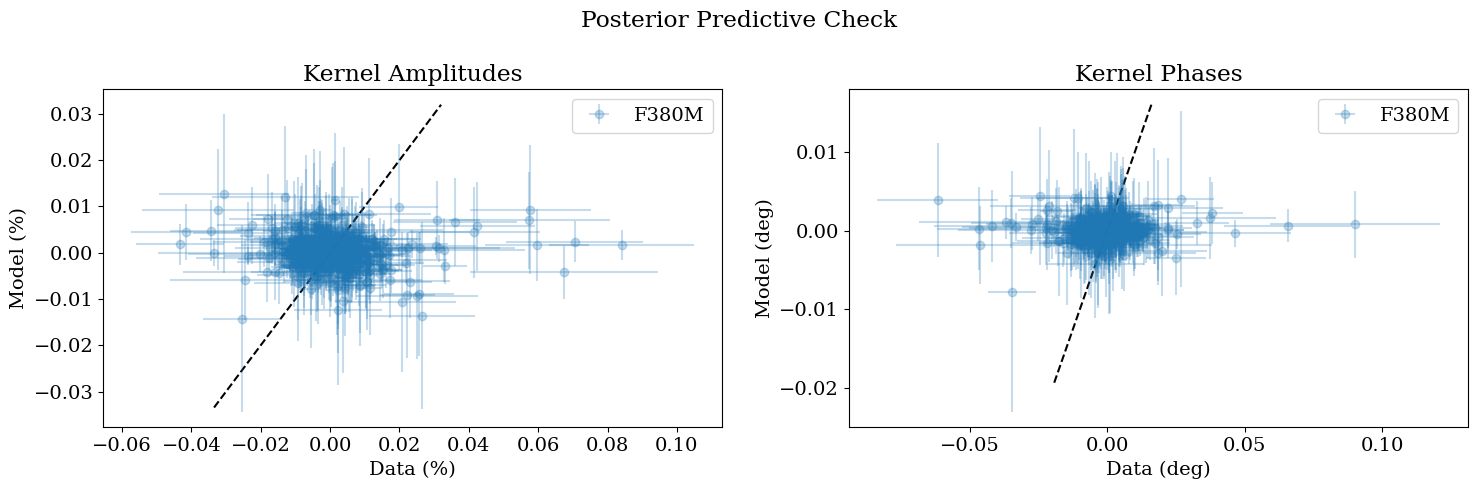

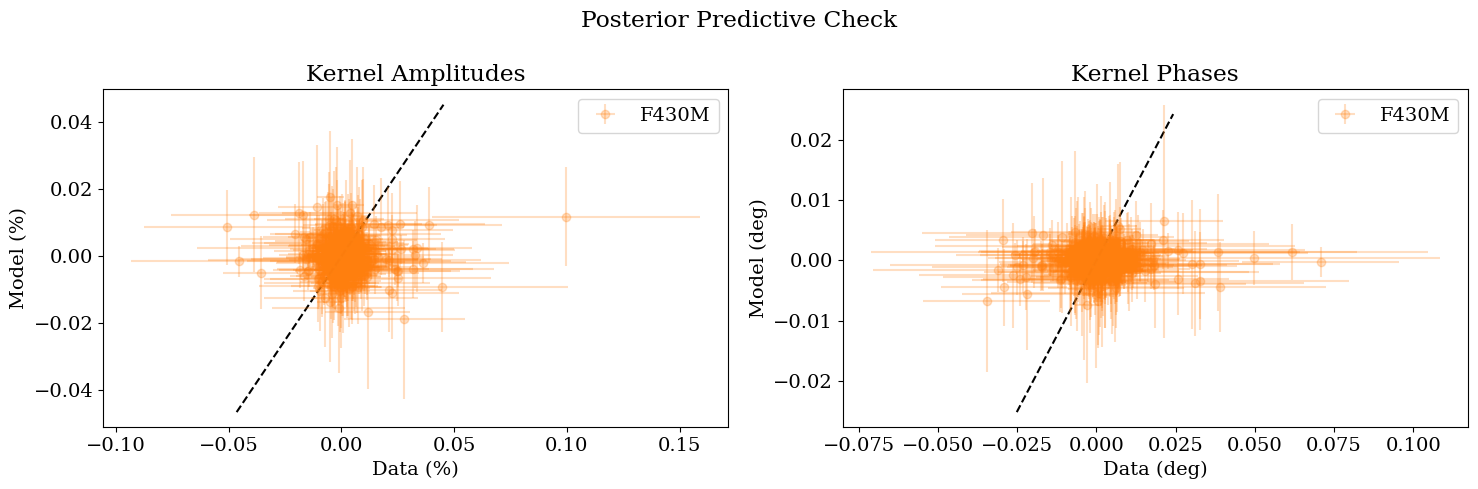

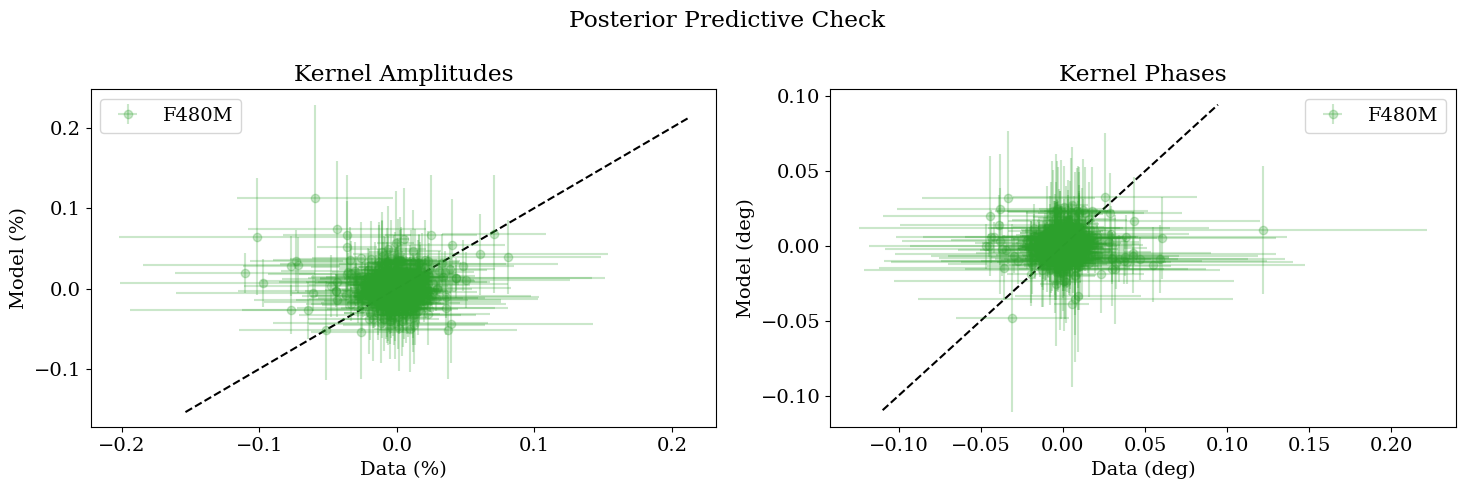

In [15]:
import pandas as pd
from chainconsumer import ChainConsumer, Chain, Truth, PlotConfig

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
# plt.suptitle("Posterior Predictive Check")
for i, (filt, oi_data_obj) in enumerate(oi_objs.items()):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    plt.suptitle("Posterior Predictive Check")

    sampler = samplers[filt]

    posterior_pred = sampler.get_samples()["pred"]
    posterior_mean = np.mean(posterior_pred, axis=0)
    posterior_std = np.std(posterior_pred, axis=0)
    n = len(oi_data_obj.K_vis)

    K_vis = oi_data_obj.K_vis
    K_phi = oi_data_obj.K_phi
    dK_vis = oi_data_obj.dK_vis
    dK_phi = oi_data_obj.dK_phi

    K_vis_pred = dlu.rad2deg(posterior_mean)[:n]
    K_phi_pred = dlu.rad2deg(posterior_mean)[n:]
    K_vis_std = dlu.rad2deg(posterior_std)[:n]
    K_phi_std = dlu.rad2deg(posterior_std)[n:]

    vis_med = np.median(K_vis_std)
    vis_min, vis_max = K_vis_pred.min(), K_vis_pred.max()
    vis_121 = np.linspace(vis_min - 5 * vis_med, vis_max + 5 * vis_med, 100)

    phi_med = np.median(K_phi_std)
    phi_min, phi_max = K_phi_pred.min(), K_phi_pred.max()
    phi_121 = np.linspace(phi_min - 5 * phi_med, phi_max + 5 * phi_med, 100)

    # plot data
    ax1.plot(vis_121, vis_121, "k--")
    ax1.errorbar(
        K_vis,
        K_vis_pred,
        xerr=dK_vis,
        yerr=K_vis_std,
        fmt="o",
        alpha=0.25,
        color=f"C{i}",
        label=filt,
    )

    ax2.plot(phi_121, phi_121, "k--")
    ax2.errorbar(
        K_phi,
        K_phi_pred,
        xerr=dK_phi,
        yerr=K_phi_std,
        fmt="o",
        alpha=0.25,
        color=f"C{i}",
        label=filt,
    )

    ax1.set(
        title="Kernel Amplitudes",
        xlabel="Data (%)",
        ylabel="Model (%)",
    )

    ax2.set(
        title="Kernel Phases",
        xlabel="Data (deg)",
        ylabel="Model (deg)",
    )
    ax1.legend()
    ax2.legend()

    plt.tight_layout()
    plt.show()

Parameter Δ Dec in chain F380M is not constrained
Parameter Δ RA in chain F430M is not constrained
Parameter Δ RA in chain F480M is not constrained


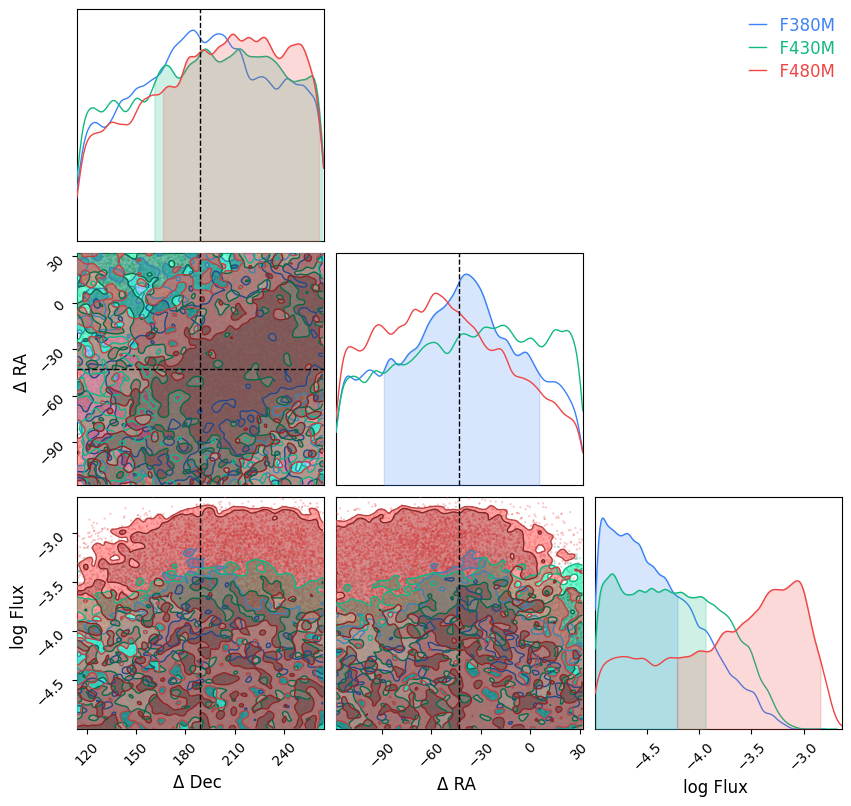

In [16]:
true_ra, true_dec = binaries[0]
truths = {
    "Δ Dec": true_dec,
    "Δ RA": true_ra,
    "log Flux": -1.78,
}

c = ChainConsumer()
c.add_truth(Truth(location=truths))

for filt, sampler in samplers.items():
    results = sampler.get_samples()
    results = {key: results[key] for key in ["Δ Dec", "Δ RA", "log Flux"]}
    cc_df = pd.DataFrame.from_dict(results)

    c.add_chain(
        Chain(
            samples=cc_df,
            name=filt,
            plot_cloud=True,
            marker_style="*",
            marker_size=100,
        )
    )

c.plotter.plot()
plt.show()

Parameter PA in chain F380M is not constrained
Parameter PA in chain F430M is not constrained


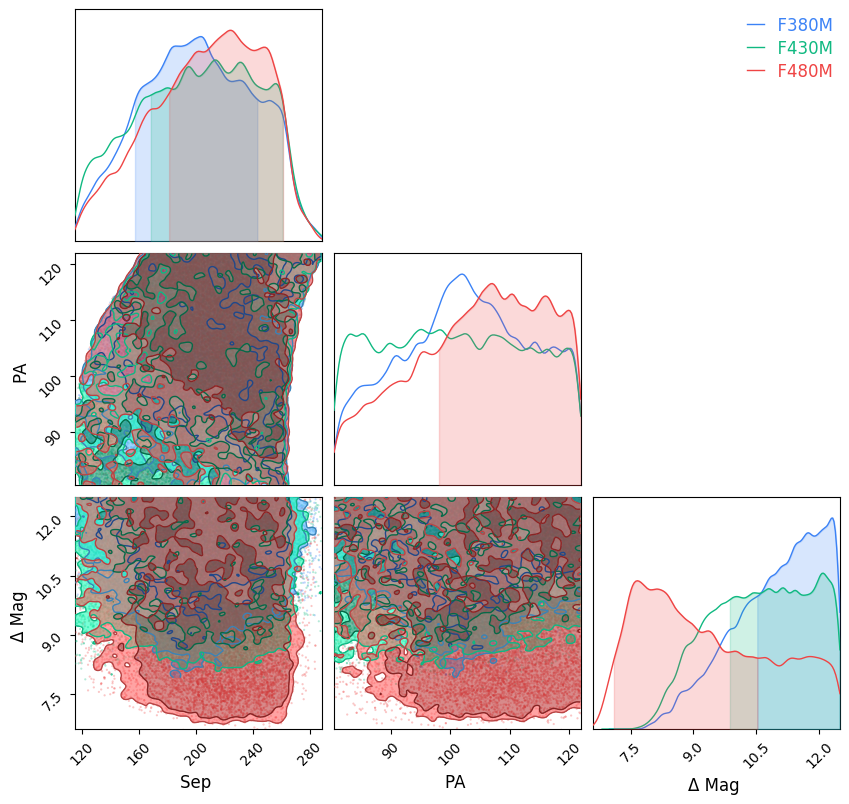

: 

In [ ]:
true_ra, true_dec = binaries[0]
truths = {
    "PA": 170,
    "Sep": 328,
    "Δ Mag": 4.42,
}

c = ChainConsumer()
c.add_truth(Truth(location=truths))

for filt, sampler in samplers.items():
    results = sampler.get_samples()
    results = {key: results[key] for key in ["Sep", "PA", "Δ Mag"]}

    cc_df = pd.DataFrame.from_dict(results)

    c.add_chain(
        Chain(
            samples=cc_df,
            name=filt,
            plot_cloud=True,
            marker_style="*",
            marker_size=100,
        )
    )

c.plotter.plot()
plt.show()